# Taller: Ecuación de Poisson — Ejemplo 1
## Diferencias Finitas en C++, Python y Fortran

---

## Bloque 1 — Fundamentos Matemáticos

### §1. Formulación del problema

**Ecuación de Poisson:**

$$\nabla^2 V = \frac{\partial^2 V}{\partial x^2} + \frac{\partial^2 V}{\partial y^2} = (x^2 + y^2)\,e^{xy}$$

**Dominio espacial:**

$$\Omega = \{(x,y) \mid x \in [0,\,2],\; y \in [0,\,1]\}$$

**Condiciones de frontera (Dirichlet):**

| Frontera | Condición |
|----------|-----------|
| $x = 0$ | $V(0,y) = 1$ |
| $x = 2$ | $V(2,y) = e^{2y}$ |
| $y = 0$ | $V(x,0) = 1$ |
| $y = 1$ | $V(x,1) = e^{x}$ |

**Solución analítica:**

$$\boxed{V(x,y) = e^{xy}}$$

**Verificación:**

$$\frac{\partial^2 V}{\partial x^2} = y^2 e^{xy}, \qquad \frac{\partial^2 V}{\partial y^2} = x^2 e^{xy} \qquad \Rightarrow \quad \nabla^2 V = (x^2+y^2)e^{xy} \checkmark$$


### §2. Discretización por Diferencias Finitas

Se divide el dominio con $N_x = N$ intervalos en $x$ y $N_y = N$ en $y$, dando pasos:

$$h_x = \frac{2}{N}, \qquad h_y = \frac{1}{N}$$

Los puntos interiores son $(x_i, y_j)$ con $i=1,\dots,N_x-1$ y $j=1,\dots,N_y-1$.

El operador Laplaciano se aproxima con el esquema de 5 puntos:

$$\frac{V_{i-1,j} - 2V_{i,j} + V_{i+1,j}}{h_x^2} + \frac{V_{i,j-1} - 2V_{i,j} + V_{i,j+1}}{h_y^2} = f_{i,j}$$

donde $f_{i,j} = (x_i^2 + y_j^2)\,e^{x_i y_j}$.

**Enumeración global:** se asigna índice $k = j(N_x-1) + i$ a cada punto interior.

Esto da un sistema lineal **disperso** de tamaño $n=(N_x-1)(N_y-1)$:

$$A\,\mathbf{v} = \mathbf{b}$$

donde $A$ es **simétrica, definida positiva** con estructura de bloques tridiagonales y ancho de banda $\approx N_x$.

**Convergencia esperada:** el error decrece como $\mathcal{O}(h^2)$, con orden $p \approx 2$.


---

## Bloque 2 — Implementaciones

### §3. C++ con Eigen (SparseLU)

Se emplea la biblioteca **Eigen 3** para construir la matriz dispersa $A$ y resolverla con `SparseLU`.

**Estrategia:**
1. Se declara `SparseMatrix<double>` de tamaño $n \times n$.
2. Se recorren los nodos interiores y se insertan los coeficientes de la 5-estrella.
3. Se aplican las condiciones de frontera trasladando las contribuciones conocidas al RHS.
4. La factorización `SparseLU` resuelve el sistema en $\mathcal{O}(n^{3/2})$ para mallados 2D.

**Fragmento clave:**
```cpp
SparseMatrix<double> A(sz, sz);
VectorXd b(sz);
A.reserve(VectorXi::Constant(sz, 5));

for (int j = 0; j < ny; ++j)
for (int i = 0; i < nx; ++i) {
    int k = j*nx + i;
    A.coeffRef(k,k) = -(2./hx2 + 2./hy2);
    if (i>0)  A.coeffRef(k, k-1)  += 1./hx2;
    if (i<nx-1) A.coeffRef(k, k+1) += 1./hx2;
    if (j>0)  A.coeffRef(k, k-nx) += 1./hy2;
    if (j<ny-1) A.coeffRef(k, k+nx) += 1./hy2;
    b(k) = rhs(x[i], y[j]);
}

SparseLU<SparseMatrix<double>> solver;
solver.analyzePattern(A);
solver.factorize(A);
VectorXd V = solver.solve(b);
```

**Compilación:** `g++ -O2 -std=c++17 -I/usr/include/eigen3 poisson.cpp -o poisson`


In [1]:
import subprocess, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"

# Compilar C++ con Eigen
result = subprocess.run(
    ["g++", "-O2", "-std=c++17", "-I/usr/include/eigen3",
     "poisson.cpp", "-o", "poisson"],
    cwd=WORK, capture_output=True, text=True
)
if result.returncode == 0:
    print("✅ poisson (Eigen) compilado correctamente")
else:
    print("❌ Error de compilación:")
    print(result.stderr)


✅ poisson (Eigen) compilado correctamente


In [2]:
import subprocess, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"

# Ejecutar C++ para diferentes tamaños de mallado
grids_cpp = [32, 64, 128, 256, 512]
print("Ejecutando C++ (Eigen) para N =", grids_cpp)
for N in grids_cpp:
    r = subprocess.run(["./poisson", str(N)], cwd=WORK, capture_output=True, text=True)
    out = r.stdout.strip().split("\n")[-1] if r.stdout else r.stderr.strip()
    print(f"  N={N:4d}: {out}")
print("✅ Resultados guardados en metrics.csv y sol_N_eigen.csv")


Ejecutando C++ (Eigen) para N = [32, 64, 128, 256, 512]
  N=  32:   CSV: sol_32_eigen.csv
  N=  64:   CSV: sol_64_eigen.csv
  N= 128:   CSV: sol_128_eigen.csv
  N= 256:   CSV: sol_256_eigen.csv
  N= 512:   CSV: sol_512_eigen.csv
✅ Resultados guardados en metrics.csv y sol_N_eigen.csv


In [8]:
import pandas as pd, numpy as np, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"

df = pd.read_csv(os.path.join(WORK, "metrics.csv"))
df.sort_values("N", inplace=True)
df.drop_duplicates(subset="N", keep="last", inplace=True)
df.reset_index(drop=True, inplace=True)
df["h"] = 2.0 / df["N"]
df["time_s"] = df["time_ms"] / 1000.0
df.rename(columns={"errL2": "error_L2", "errMax": "error_Max", "mem_MB": "memory_MB"}, inplace=True)

# Calcular orden de convergencia
def conv_order(err):
    return [np.nan] + [np.log(err.iloc[i-1]/err.iloc[i])/np.log(2) for i in range(1, len(err))]

df["p_L2"]  = conv_order(df["error_L2"])
df["p_Max"] = conv_order(df["error_Max"])

display_df = df[["N","h","error_L2","error_Max","p_L2","p_Max","time_s","memory_MB"]].copy()
display_df.columns = ["N","h","Error L2","Error Max","p(L2)","p(Max)","t(s)","Mem(MB)"]

fmt = {"h":"{:.4f}","Error L2":"{:.2e}","Error Max":"{:.2e}",
       "p(L2)":"{:.2f}","p(Max)":"{:.2f}","t(s)":"{:.4f}","Mem(MB)":"{:.1f}"}
print("\n=== C++ Eigen SparseLU — Estudio de Mallado ===")
print(display_df.to_string(index=False, formatters={k: (lambda v,f=f: f.format(v) if pd.notna(v) else "—") for k,f in fmt.items()}))



=== C++ Eigen SparseLU — Estudio de Mallado ===
  N      h Error L2 Error Max p(L2) p(Max)   t(s) Mem(MB)
 32 0.0625 4.38e-05  1.06e-04   NaN    NaN 0.0057     0.1
 64 0.0312 1.12e-05  2.75e-05  1.97   1.95 0.0829     0.4
128 0.0156 2.81e-06  7.00e-06  1.99   1.98 0.5584     1.6
256 0.0078 7.06e-07  1.76e-06  1.99   1.99 0.7814     6.2
512 0.0039 1.77e-07  4.42e-07  2.00   1.99 5.7386    25.0


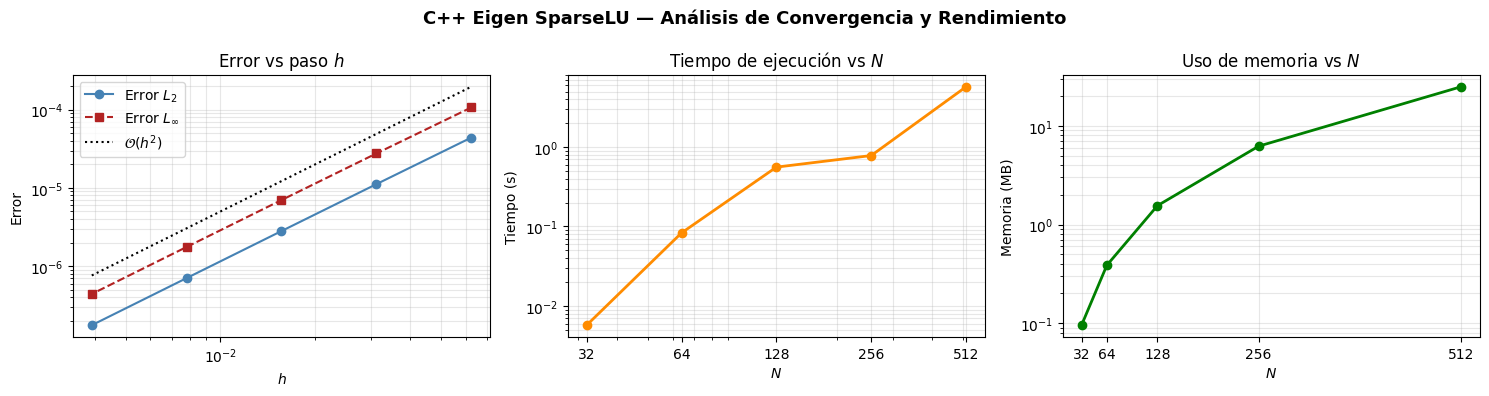

In [9]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"

df = pd.read_csv(os.path.join(WORK, "metrics.csv"))
df.sort_values("N", inplace=True)
df.drop_duplicates(subset="N", keep="last", inplace=True)
df.reset_index(drop=True, inplace=True)
df["h"] = 2.0 / df["N"]
df["time_s"] = df["time_ms"] / 1000.0
df.rename(columns={"errL2": "error_L2", "errMax": "error_Max", "mem_MB": "memory_MB"}, inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("C++ Eigen SparseLU — Análisis de Convergencia y Rendimiento", fontsize=13, fontweight="bold")

ax = axes[0]
ax.loglog(df["h"], df["error_L2"],  "o-", label="Error $L_2$",  color="steelblue")
ax.loglog(df["h"], df["error_Max"], "s--", label="Error $L_\\infty$", color="firebrick")
h_ref = np.sort(df["h"].values)
ax.loglog(h_ref, 0.05*h_ref**2, "k:", label="$\\mathcal{O}(h^2)$")
ax.set_xlabel("$h$"); ax.set_ylabel("Error"); ax.set_title("Error vs paso $h$")
ax.legend(); ax.grid(True, which="both", alpha=0.3)

ax = axes[1]
ax.loglog(df["N"], df["time_s"], "o-", color="darkorange", lw=2)
ax.set_xlabel("$N$"); ax.set_ylabel("Tiempo (s)"); ax.set_title("Tiempo de ejecución vs $N$")
ax.grid(True, which="both", alpha=0.3)
ax.set_xticks(df["N"]); ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax = axes[2]
ax.semilogy(df["N"], df["memory_MB"], "o-", color="green", lw=2)
ax.set_xlabel("$N$"); ax.set_ylabel("Memoria (MB)"); ax.set_title("Uso de memoria vs $N$")
ax.grid(True, which="both", alpha=0.3)
ax.set_xticks(df["N"]); ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.tight_layout()
plt.savefig(os.path.join(WORK, "cpp_analysis.png"), dpi=100, bbox_inches="tight")
plt.show()


### §4. Python con scipy.sparse

Se usa **`scipy.sparse`** para construir la matriz en formato `lil_matrix` (inserción eficiente) y luego convertirla a `csr_matrix` para el solver.

**Estrategia:**
1. `lil_matrix` permite asignación fila/columna sin overhead.
2. Conversión a `csr_matrix` antes de resolver.
3. `spsolve` de `scipy.sparse.linalg` invoca internamente SuperLU (análogo a Eigen SparseLU).

**Fragmento clave:**
```python
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

A = lil_matrix((sz, sz))
for j in range(ny):
    for i in range(nx):
        k = j*nx + i
        A[k, k] = -(2/hx2 + 2/hy2)
        if i > 0:     A[k, k-1]  += 1/hx2
        if i < nx-1:  A[k, k+1]  += 1/hx2
        if j > 0:     A[k, k-nx] += 1/hy2
        if j < ny-1:  A[k, k+nx] += 1/hy2

V = spsolve(A.tocsr(), b)
```

**Ejecución:** `python poisson_scipy.py N`


In [7]:
import subprocess, sys, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"
PYTHON = sys.executable

grids_py = [32, 64, 128, 256, 512]
print("Ejecutando Python (scipy) para N =", grids_py)
for N in grids_py:
    r = subprocess.run([PYTHON, "poisson_scipy.py", str(N)], cwd=WORK, capture_output=True, text=True)
    out = r.stdout.strip().split("\n")[-1] if r.stdout else r.stderr.strip()
    print(f"  N={N:4d}: {out}")
print("✅ Resultados guardados en metrics_python.csv y sol_N_python.csv")


Ejecutando Python (scipy) para N = [32, 64, 128, 256, 512]
  N=  32:   CSV: sol_32_python.csv
  N=  64:   CSV: sol_64_python.csv
  N= 128:   CSV: sol_128_python.csv
  N= 256:   CSV: sol_256_python.csv
  N= 512:   CSV: sol_512_python.csv
✅ Resultados guardados en metrics_python.csv y sol_N_python.csv


In [10]:
import pandas as pd, numpy as np, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"

df = pd.read_csv(os.path.join(WORK, "metrics_python.csv"))
df.sort_values("N", inplace=True)
df.drop_duplicates(subset="N", keep="last", inplace=True)
df.reset_index(drop=True, inplace=True)
df["h"] = 2.0 / df["N"]
df["time_s"] = df["time_ms"] / 1000.0
df.rename(columns={"errL2": "error_L2", "errMax": "error_Max", "mem_MB": "memory_MB"}, inplace=True)

def conv_order(err):
    return [np.nan] + [np.log(err.iloc[i-1]/err.iloc[i])/np.log(2) for i in range(1, len(err))]

df["p_L2"]  = conv_order(df["error_L2"])
df["p_Max"] = conv_order(df["error_Max"])

display_df = df[["N","h","error_L2","error_Max","p_L2","p_Max","time_s","memory_MB"]].copy()
display_df.columns = ["N","h","Error L2","Error Max","p(L2)","p(Max)","t(s)","Mem(MB)"]

fmt = {"h":"{:.4f}","Error L2":"{:.2e}","Error Max":"{:.2e}",
       "p(L2)":"{:.2f}","p(Max)":"{:.2f}","t(s)":"{:.4f}","Mem(MB)":"{:.1f}"}
print("\n=== Python scipy.sparse.spsolve — Estudio de Mallado ===")
print(display_df.to_string(index=False, formatters={k: (lambda v,f=f: f.format(v) if pd.notna(v) else "—") for k,f in fmt.items()}))



=== Python scipy.sparse.spsolve — Estudio de Mallado ===
  N      h Error L2 Error Max p(L2) p(Max)    t(s) Mem(MB)
 32 0.0625 4.38e-05  1.06e-04   NaN    NaN  0.0289     0.1
 64 0.0312 1.12e-05  2.75e-05  1.97   1.95  0.1490     0.4
128 0.0156 2.81e-06  7.00e-06  1.99   1.98  0.5976     1.6
256 0.0078 7.06e-07  1.76e-06  1.99   1.99  3.7450     6.2
512 0.0039 1.77e-07  4.42e-07  2.00   1.99 23.0676    25.0


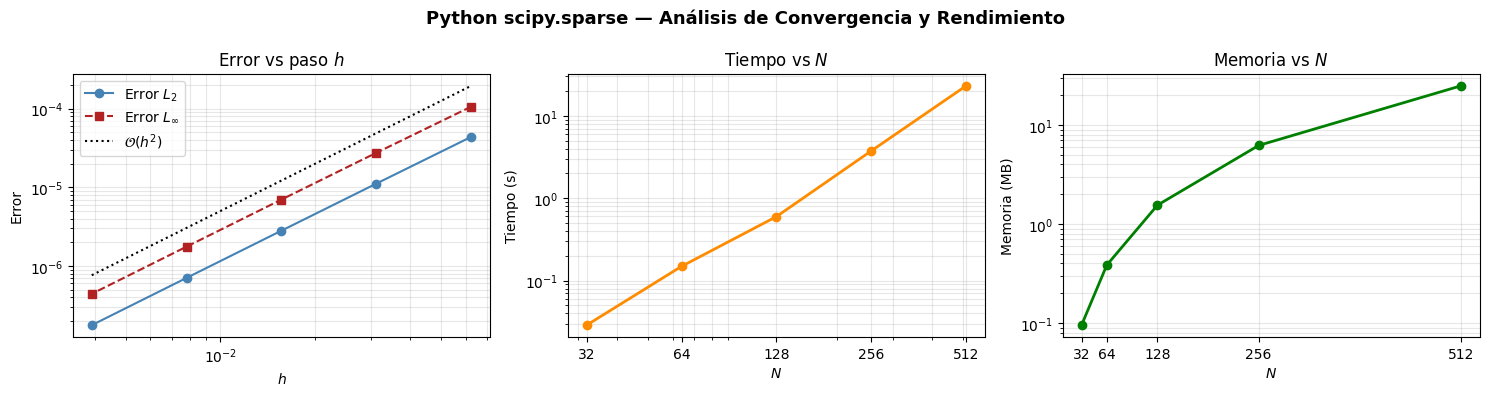

In [11]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"

df = pd.read_csv(os.path.join(WORK, "metrics_python.csv"))
df.sort_values("N", inplace=True)
df.drop_duplicates(subset="N", keep="last", inplace=True)
df.reset_index(drop=True, inplace=True)
df["h"] = 2.0 / df["N"]
df["time_s"] = df["time_ms"] / 1000.0
df.rename(columns={"errL2": "error_L2", "errMax": "error_Max", "mem_MB": "memory_MB"}, inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Python scipy.sparse — Análisis de Convergencia y Rendimiento", fontsize=13, fontweight="bold")

ax = axes[0]
ax.loglog(df["h"], df["error_L2"],  "o-", label="Error $L_2$",  color="steelblue")
ax.loglog(df["h"], df["error_Max"], "s--", label="Error $L_\\infty$", color="firebrick")
h_ref = np.sort(df["h"].values)
ax.loglog(h_ref, 0.05*h_ref**2, "k:", label="$\\mathcal{O}(h^2)$")
ax.set_xlabel("$h$"); ax.set_ylabel("Error"); ax.set_title("Error vs paso $h$")
ax.legend(); ax.grid(True, which="both", alpha=0.3)

ax = axes[1]
ax.loglog(df["N"], df["time_s"], "o-", color="darkorange", lw=2)
ax.set_xlabel("$N$"); ax.set_ylabel("Tiempo (s)"); ax.set_title("Tiempo vs $N$")
ax.grid(True, which="both", alpha=0.3)
ax.set_xticks(df["N"]); ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax = axes[2]
ax.semilogy(df["N"], df["memory_MB"], "o-", color="green", lw=2)
ax.set_xlabel("$N$"); ax.set_ylabel("Memoria (MB)"); ax.set_title("Memoria vs $N$")
ax.grid(True, which="both", alpha=0.3)
ax.set_xticks(df["N"]); ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.tight_layout()
plt.savefig(os.path.join(WORK, "python_analysis.png"), dpi=100, bbox_inches="tight")
plt.show()


### §5. Fortran con LAPACK (dgbsv — solver de banda)

Se usa **LAPACK** `dgbsv` para resolver el sistema lineal en formato de **matriz de banda**.

**Motivación:** la matriz $A$ tiene ancho de banda $k_l = k_u = N_x - 1$, lo que permite almacenarla en formato de banda con memoria $\mathcal{O}((2k_l+k_u+1)\cdot n)$ en lugar de $\mathcal{O}(n^2)$.

**Estrategia:**
1. Se llena la matriz en formato de banda `AB((2*kl+ku+1) × sz)`.
2. `dgbsv` factoriza con LU parcial el sistema banda.
3. La solución se escribe a CSV para análisis posterior.

**Limitación:** para $N > 128$ el ancho de banda $k_l = N-1$ hace que la memoria de la banda supere la de la dispersa Eigen, por lo que solo se prueban $N \leq 128$.

**Fragmento clave (Fortran):**
```fortran
ldab = 2*kl + ku + 1
allocate(AB(ldab, sz), ipiv(sz), bvec(sz))
! Diagonal principal en fila kl+ku+1
AB(kl+ku+1, k) = -(2.d0/hx2 + 2.d0/hy2)
! Vecinos horizontales
AB(kl+ku+1-1, k+1) = 1.d0/hx2   ! superdiagonal
AB(kl+ku+1+1, k-1) = 1.d0/hx2   ! subdiagonal
call dgbsv(sz, kl, ku, 1, AB, ldab, ipiv, bvec, sz, info)
```

**Compilación:** `gfortran -O2 poisson.f90 -o poisson_f -llapack -lblas`


In [1]:
import subprocess, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"

# Compilar Fortran
res = subprocess.run(
    ["gfortran", "-O2", "poisson.f90", "-o", "poisson_f", "-llapack", "-lblas"],
    cwd=WORK, capture_output=True, text=True
)
if res.returncode == 0:
    print("✅ poisson_f (Fortran LAPACK) compilado correctamente")
else:
    print("❌ Error:"); print(res.stderr)

# Ejecutar para N = 32, 64, 128
grids_f90 = [32, 64, 128, 256]
print(f"\nEjecutando Fortran para N = {grids_f90}")
for N in grids_f90:
    r = subprocess.run(["./poisson_f", str(N)], cwd=WORK, capture_output=True, text=True)
    out = r.stdout.strip().split("\n")[-1] if r.stdout else r.stderr.strip()
    print(f"  N={N:4d}: {out}")
print("✅ Resultados guardados en metrics_fortran.csv y sol_N_fortran.csv")


✅ poisson_f (Fortran LAPACK) compilado correctamente

Ejecutando Fortran para N = [32, 64, 128, 256]
  N=  32:   CSV: sol_32_fortran.csv
  N=  64:   CSV: sol_64_fortran.csv
  N= 128:   CSV: sol_128_fortran.csv
  N= 256:   CSV: sol_256_fortran.csv
✅ Resultados guardados en metrics_fortran.csv y sol_N_fortran.csv


In [12]:
import pandas as pd, numpy as np, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"

df = pd.read_csv(os.path.join(WORK, "metrics_fortran.csv"))
df.sort_values("N", inplace=True)
df.drop_duplicates(subset="N", keep="last", inplace=True)
df.reset_index(drop=True, inplace=True)
df["h"] = 2.0 / df["N"]
df["time_s"] = df["time_ms"] / 1000.0
df.rename(columns={"errL2": "error_L2", "errMax": "error_Max", "mem_MB": "memory_MB"}, inplace=True)

def conv_order(err):
    return [np.nan] + [np.log(err.iloc[i-1]/err.iloc[i])/np.log(2) for i in range(1, len(err))]

df["p_L2"]  = conv_order(df["error_L2"])
df["p_Max"] = conv_order(df["error_Max"])

display_df = df[["N","h","error_L2","error_Max","p_L2","p_Max","time_s","memory_MB"]].copy()
display_df.columns = ["N","h","Error L2","Error Max","p(L2)","p(Max)","t(s)","Mem(MB)"]

fmt = {"h":"{:.4f}","Error L2":"{:.2e}","Error Max":"{:.2e}",
       "p(L2)":"{:.2f}","p(Max)":"{:.2f}","t(s)":"{:.4f}","Mem(MB)":"{:.1f}"}
print("\n=== Fortran LAPACK dgbsv — Estudio de Mallado ===")
print(display_df.to_string(index=False, formatters={k: (lambda v,f=f: f.format(v) if pd.notna(v) else "—") for k,f in fmt.items()}))



=== Fortran LAPACK dgbsv — Estudio de Mallado ===
  N      h Error L2 Error Max p(L2) p(Max)    t(s) Mem(MB)
 32 0.0625 4.38e-05  1.06e-04   NaN    NaN  0.0633     0.8
 64 0.0312 1.12e-05  2.75e-05  1.97   1.95  0.4984     6.0
128 0.0156 2.81e-06  7.00e-06  1.99   1.98  1.3776    48.1
256 0.0078 7.06e-07  1.76e-06  1.99   1.99 19.1120   384.5


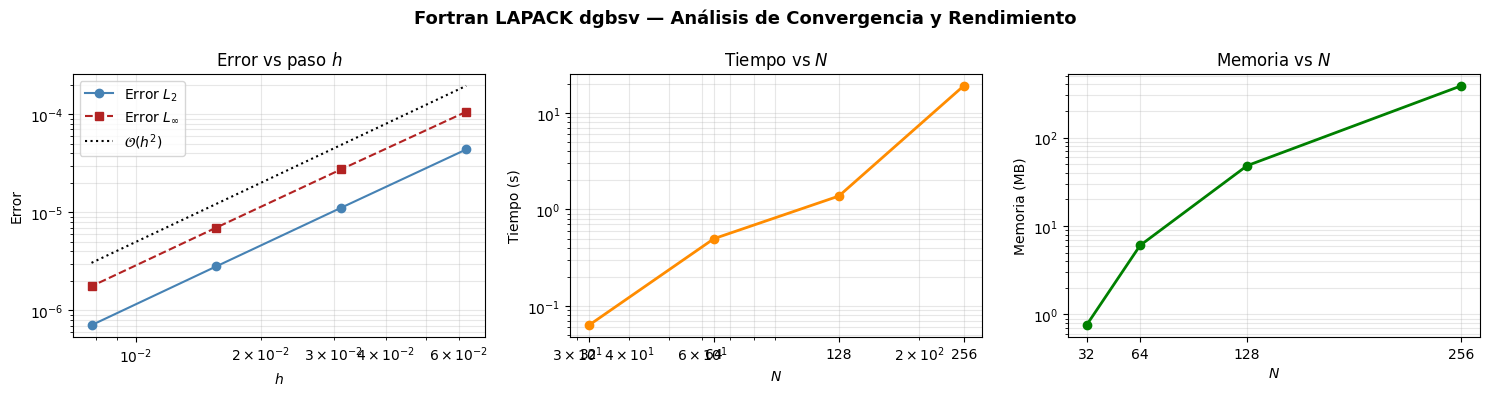

In [13]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"

df = pd.read_csv(os.path.join(WORK, "metrics_fortran.csv"))
df.sort_values("N", inplace=True)
df.drop_duplicates(subset="N", keep="last", inplace=True)
df.reset_index(drop=True, inplace=True)
df["h"] = 2.0 / df["N"]
df["time_s"] = df["time_ms"] / 1000.0
df.rename(columns={"errL2": "error_L2", "errMax": "error_Max", "mem_MB": "memory_MB"}, inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Fortran LAPACK dgbsv — Análisis de Convergencia y Rendimiento", fontsize=13, fontweight="bold")

ax = axes[0]
ax.loglog(df["h"], df["error_L2"],  "o-", label="Error $L_2$",  color="steelblue")
ax.loglog(df["h"], df["error_Max"], "s--", label="Error $L_\\infty$", color="firebrick")
h_ref = np.sort(df["h"].values)
ax.loglog(h_ref, 0.05*h_ref**2, "k:", label="$\\mathcal{O}(h^2)$")
ax.set_xlabel("$h$"); ax.set_ylabel("Error"); ax.set_title("Error vs paso $h$")
ax.legend(); ax.grid(True, which="both", alpha=0.3)

ax = axes[1]
ax.loglog(df["N"], df["time_s"], "o-", color="darkorange", lw=2)
ax.set_xlabel("$N$"); ax.set_ylabel("Tiempo (s)"); ax.set_title("Tiempo vs $N$")
ax.grid(True, which="both", alpha=0.3)
ax.set_xticks(df["N"]); ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax = axes[2]
ax.semilogy(df["N"], df["memory_MB"], "o-", color="green", lw=2)
ax.set_xlabel("$N$"); ax.set_ylabel("Memoria (MB)"); ax.set_title("Memoria vs $N$")
ax.grid(True, which="both", alpha=0.3)
ax.set_xticks(df["N"]); ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.tight_layout()
plt.savefig(os.path.join(WORK, "fortran_analysis.png"), dpi=100, bbox_inches="tight")
plt.show()


---

## Bloque 3 — Análisis de Resultados

### §6. Visualización interactiva de soluciones

El widget permite explorar la solución numérica, la solución exacta y el error puntual para cualquier combinación de **lenguaje/solver** y **tamaño de mallado** disponible en disco.

- **Lenguaje:** C++ (Eigen), Python (scipy), Fortran (LAPACK)
- **N:** cualquier valor con CSV generado
- **Mapa de color:** seleccionable
- **Toggle error:** muestra diferencia $|V_{num} - V_{exact}|$


In [14]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, os, glob

WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"

# --- Detectar archivos disponibles ---
suffix_map = {"C++ (Eigen)": "eigen", "Python (scipy)": "python", "Fortran (LAPACK)": "fortran"}

def available_grids(lang_key):
    suf = suffix_map[lang_key]
    files = glob.glob(os.path.join(WORK, f"sol_*_{suf}.csv"))
    Ns = sorted([int(os.path.basename(f).split("_")[1]) for f in files])
    return Ns

# --- Widgets ---
lang_dd = widgets.Dropdown(
    options=list(suffix_map.keys()), description="Lenguaje:", style={"description_width": "90px"}
)
N_dd = widgets.Dropdown(description="N:", style={"description_width": "40px"})
cmap_dd = widgets.Dropdown(
    options=["viridis","plasma","inferno","coolwarm","jet"], value="viridis",
    description="Colormap:", style={"description_width": "80px"}
)
err_toggle = widgets.Checkbox(value=False, description="Mostrar error", style={"description_width": "initial"})

def update_N_options(change):
    ns = available_grids(lang_dd.value)
    N_dd.options = ns if ns else [32]
    N_dd.value = ns[0] if ns else 32

lang_dd.observe(update_N_options, names="value")
update_N_options(None)

out = widgets.Output()

def plot_solution(lang, N, cmap, show_err):
    suf = suffix_map[lang]
    fpath = os.path.join(WORK, f"sol_{N}_{suf}.csv")
    if not os.path.exists(fpath):
        print(f"Archivo {fpath} no encontrado. Ejecuta primero la celda de ejecución correspondiente.")
        return

    data = pd.read_csv(fpath)
    xs = np.sort(data["x"].unique())
    ys = np.sort(data["y"].unique())
    Nx, Ny = len(xs), len(ys)
    Vnum   = data.pivot(index="y", columns="x", values="V_num").values
    Vexact = data.pivot(index="y", columns="x", values="V_exact").values
    Err    = np.abs(Vnum - Vexact)
    X, Y   = np.meshgrid(xs, ys)

    ncols = 3 if show_err else 2
    fig, axes = plt.subplots(1, ncols, figsize=(5.5*ncols, 4))
    fig.suptitle(f"{lang} — N={N}  (h_x={2/N:.4f}, h_y={1/N:.4f})", fontsize=12, fontweight="bold")

    panels = [("$V_{num}$", Vnum), ("$V_{exact}$", Vexact)]
    if show_err:
        panels.append(("$|V_{num}-V_{exact}|$", Err))

    for ax, (title, Z) in zip(axes, panels):
        pcm = ax.pcolormesh(X, Y, Z, cmap=cmap, shading="auto")
        fig.colorbar(pcm, ax=ax)
        ax.set_title(title); ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
        ax.set_aspect("auto")

    plt.tight_layout()
    plt.show()

def on_change(_):
    out.clear_output(wait=True)
    with out:
        plot_solution(lang_dd.value, N_dd.value, cmap_dd.value, err_toggle.value)

for w in [lang_dd, N_dd, cmap_dd, err_toggle]:
    w.observe(on_change, names="value")

ui = widgets.HBox([lang_dd, N_dd, cmap_dd, err_toggle])
display(ui, out)
on_change(None)


Output()

### §7. Tablas comparativas entre lenguajes

Se comparan los tres solvers para los mallados comunes ($N \in \{32, 64, 128\}$) y se calcula el **speedup** relativo.


In [15]:
import pandas as pd, numpy as np, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"

def load_metrics(fname):
    df = pd.read_csv(os.path.join(WORK, fname))
    df.sort_values("N", inplace=True)
    df.drop_duplicates(subset="N", keep="last", inplace=True)
    df.reset_index(drop=True, inplace=True)
    df["h"] = 2.0 / df["N"]
    df["time_s"] = df["time_ms"] / 1000.0
    df.rename(columns={"errL2": "error_L2", "errMax": "error_Max", "mem_MB": "memory_MB"}, inplace=True)
    return df

sources = {
    "C++ (Eigen)":     "metrics.csv",
    "Python (scipy)":  "metrics_python.csv",
    "Fortran (LAPACK)":"metrics_fortran.csv",
}

dfs = {}
for lang, fname in sources.items():
    fpath = os.path.join(WORK, fname)
    if os.path.exists(fpath):
        dfs[lang] = load_metrics(fname)

common_N = [32, 64, 128]

# ---- Tabla 1: errores y p ----
rows = []
for lang, df in dfs.items():
    sub = df[df["N"].isin(common_N)].copy().reset_index(drop=True)
    err = sub["error_L2"].values
    p = [np.nan] + [np.log(err[i-1]/err[i])/np.log(2) for i in range(1, len(err))]
    for idx, (_, row) in enumerate(sub.iterrows()):
        rows.append({
            "Lenguaje": lang, "N": int(row["N"]),
            "Error L2": row["error_L2"], "Error Max": row["error_Max"],
            "p(L2)": p[idx], "t(s)": row["time_s"], "Mem(MB)": row["memory_MB"]
        })

comp = pd.DataFrame(rows)
fmt2 = {"Error L2":"{:.2e}","Error Max":"{:.2e}","p(L2)":"{:.2f}","t(s)":"{:.4f}","Mem(MB)":"{:.1f}"}
print("=== Tabla 1: Comparación global (N comunes) ===")
print(comp.to_string(index=False, formatters={k:(lambda v,f=f: f.format(v) if pd.notna(v) else "—") for k,f in fmt2.items()}))

# ---- Tabla 2: speedup relativo (tomando Python como base) ----
print("\n=== Tabla 2: Speedup relativo vs Python ===")
spd_rows = []
for N in common_N:
    times = {}
    for lang in dfs:
        match = dfs[lang][dfs[lang]["N"]==N]["time_s"]
        if len(match) > 0:
            times[lang] = match.values[0]
    if "Python (scipy)" in times:
        base = times["Python (scipy)"]
        for lang, t in times.items():
            spd_rows.append({"N": N, "Lenguaje": lang, "t(s)": t, "Speedup vs Python": base/t})

spd = pd.DataFrame(spd_rows)
print(spd.to_string(index=False, formatters={"t(s)":"{:.4f}".format,"Speedup vs Python":"{:.2f}x".format}))

# ---- Tabla 3: Mallado máximo alcanzado ----
print("\n=== Tabla 3: Mallado máximo por lenguaje ===")
for lang, df in dfs.items():
    Nmax = df["N"].max()
    mem  = df[df["N"]==Nmax]["memory_MB"].values[0]
    err  = df[df["N"]==Nmax]["error_L2"].values[0]
    print(f"  {lang:25s}: N_max={Nmax:4d}  Mem={mem:7.1f} MB  Error L2={err:.2e}")


=== Tabla 1: Comparación global (N comunes) ===
        Lenguaje   N Error L2 Error Max p(L2)   t(s) Mem(MB)
     C++ (Eigen)  32 4.38e-05  1.06e-04   NaN 0.0057     0.1
     C++ (Eigen)  64 1.12e-05  2.75e-05  1.97 0.0829     0.4
     C++ (Eigen) 128 2.81e-06  7.00e-06  1.99 0.5584     1.6
  Python (scipy)  32 4.38e-05  1.06e-04   NaN 0.0289     0.1
  Python (scipy)  64 1.12e-05  2.75e-05  1.97 0.1490     0.4
  Python (scipy) 128 2.81e-06  7.00e-06  1.99 0.5976     1.6
Fortran (LAPACK)  32 4.38e-05  1.06e-04   NaN 0.0633     0.8
Fortran (LAPACK)  64 1.12e-05  2.75e-05  1.97 0.4984     6.0
Fortran (LAPACK) 128 2.81e-06  7.00e-06  1.99 1.3776    48.1

=== Tabla 2: Speedup relativo vs Python ===
  N         Lenguaje   t(s) Speedup vs Python
 32      C++ (Eigen) 0.0057             5.05x
 32   Python (scipy) 0.0289             1.00x
 32 Fortran (LAPACK) 0.0633             0.46x
 64      C++ (Eigen) 0.0829             1.80x
 64   Python (scipy) 0.1490             1.00x
 64 Fortran (LAPACK) 

### §8. Gráficas comparativas

Tres paneles lado a lado: **tiempo de ejecución**, **uso de memoria** y **Error $L_2$** en función de $N$, uno por solver.


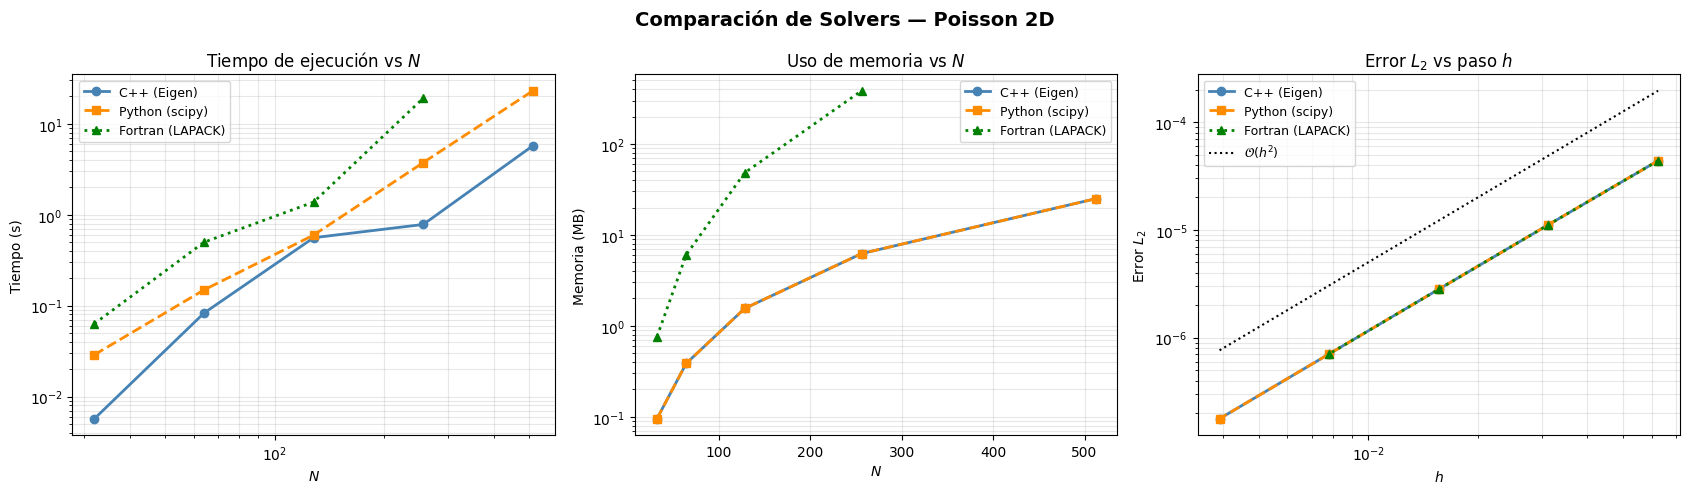

✅ Gráfica guardada en comparison_plots.png


In [16]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"

def load_metrics(fname):
    df = pd.read_csv(os.path.join(WORK, fname))
    df.sort_values("N", inplace=True)
    df.drop_duplicates(subset="N", keep="last", inplace=True)
    df.reset_index(drop=True, inplace=True)
    df["h"] = 2.0 / df["N"]
    df["time_s"] = df["time_ms"] / 1000.0
    df.rename(columns={"errL2": "error_L2", "errMax": "error_Max", "mem_MB": "memory_MB"}, inplace=True)
    return df

sources = {
    "C++ (Eigen)":     ("metrics.csv",          "steelblue",  "o-"),
    "Python (scipy)":  ("metrics_python.csv",    "darkorange", "s--"),
    "Fortran (LAPACK)":("metrics_fortran.csv",   "green",      "^:"),
}

dfs = {}
for lang, (fname, color, style) in sources.items():
    fpath = os.path.join(WORK, fname)
    if os.path.exists(fpath):
        dfs[lang] = (load_metrics(fname), color, style)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Comparación de Solvers — Poisson 2D", fontsize=14, fontweight="bold")

ax = axes[0]
for lang, (df, c, s) in dfs.items():
    ax.loglog(df["N"], df["time_s"], s, color=c, label=lang, lw=2, markersize=6)
ax.set_xlabel("$N$"); ax.set_ylabel("Tiempo (s)"); ax.set_title("Tiempo de ejecución vs $N$")
ax.legend(fontsize=9); ax.grid(True, which="both", alpha=0.3)

ax = axes[1]
for lang, (df, c, s) in dfs.items():
    ax.semilogy(df["N"], df["memory_MB"], s, color=c, label=lang, lw=2, markersize=6)
ax.set_xlabel("$N$"); ax.set_ylabel("Memoria (MB)"); ax.set_title("Uso de memoria vs $N$")
ax.legend(fontsize=9); ax.grid(True, which="both", alpha=0.3)

ax = axes[2]
for lang, (df, c, s) in dfs.items():
    ax.loglog(df["h"], df["error_L2"], s, color=c, label=lang, lw=2, markersize=6)
if dfs:
    first_df = list(dfs.values())[0][0]
    h_ref = np.sort(first_df["h"].values)
    ax.loglog(h_ref, 0.05*h_ref**2, "k:", label="$\\mathcal{O}(h^2)$", lw=1.5)
ax.set_xlabel("$h$"); ax.set_ylabel("Error $L_2$"); ax.set_title("Error $L_2$ vs paso $h$")
ax.legend(fontsize=9); ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORK, "comparison_plots.png"), dpi=120, bbox_inches="tight")
plt.show()
print("✅ Gráfica guardada en comparison_plots.png")
